# **Exercise for Unit 6**
---

**Name**  Vincent Corpes Jr. & Myrrhea Belle B. Junsay <br>			**Date:** April 24, 2026 <br>
**Year and Section:** BSCS 3A - AI

- **Task:** Emotion Classification (Multiclass: Joy, Anger, Fear, Love, Sadness, Surprise).
- **Domain:**  Social Media/Psychology (Twitter/X data).
- **LLM:** ```microsoft/deberta-v3-small.```
- **Dataset:** ```dair-ai/emotion```

1. **Install Dependencies**

In [37]:
!pip install -q transformers[torch] datasets evaluate scikit-learn matplotlib seaborn adjustText

2. **Identify and Load Model/Dataset**

In [38]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
import numpy as np

model_id = "microsoft/deberta-v3-small"
dataset_id = "dair-ai/emotion"

dataset = load_dataset(dataset_id)
tokenizer = AutoTokenizer.from_pretrained(model_id)

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

id2label = {0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}
label2id = {v: k for k, v in id2label.items()}

model = AutoModelForSequenceClassification.from_pretrained(
    model_id, num_labels=6, id2label=id2label, label2id=label2id, torch_dtype=torch.float32
)

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.bias       

3. **Configuration and Training**

In [39]:
import evaluate
from transformers import DataCollatorWithPadding

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="weighted")
    precision = precision_metric.compute(predictions=predictions, references=labels, average="weighted")
    recall = recall_metric.compute(predictions=predictions, references=labels, average="weighted")

    return {"accuracy": accuracy["accuracy"], "f1": f1["f1"], "precision": precision["precision"], "recall": recall["recall"]}

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="./emotion_model",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    report_to="none",
    fp16=False
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"].shuffle(seed=42),
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
    data_collator=data_collator,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.482692,0.327473,0.895500,0.895620,0.899565,0.895500
2,0.247868,0.224400,0.927000,0.926980,0.928962,0.927000
3,0.171371,0.216666,0.928000,0.928537,0.930478,0.928000
4,0.129423,0.234089,0.928500,0.927491,0.929697,0.928500
5,0.097574,0.238567,0.924000,0.924329,0.924933,0.924000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5000, training_loss=0.29268256149291993, metrics={'train_runtime': 831.5892, 'train_samples_per_second': 96.201, 'train_steps_per_second': 6.013, 'total_flos': 899297295042240.0, 'train_loss': 0.29268256149291993, 'epoch': 5.0})

4. **Evaluation**

In [46]:
import pandas as pd

eval_results = trainer.evaluate()

print("Evaluation Results:")
for key, value in eval_results.items():
    print(f"- {key}: {value:.4f}")

Evaluation Results:
- eval_loss: 0.2386
- eval_accuracy: 0.9240
- eval_f1: 0.9243
- eval_precision: 0.9249
- eval_recall: 0.9240
- eval_runtime: 5.6575
- eval_samples_per_second: 353.5100
- eval_steps_per_second: 44.1890
- epoch: 5.0000


5. **PCA Visualization**

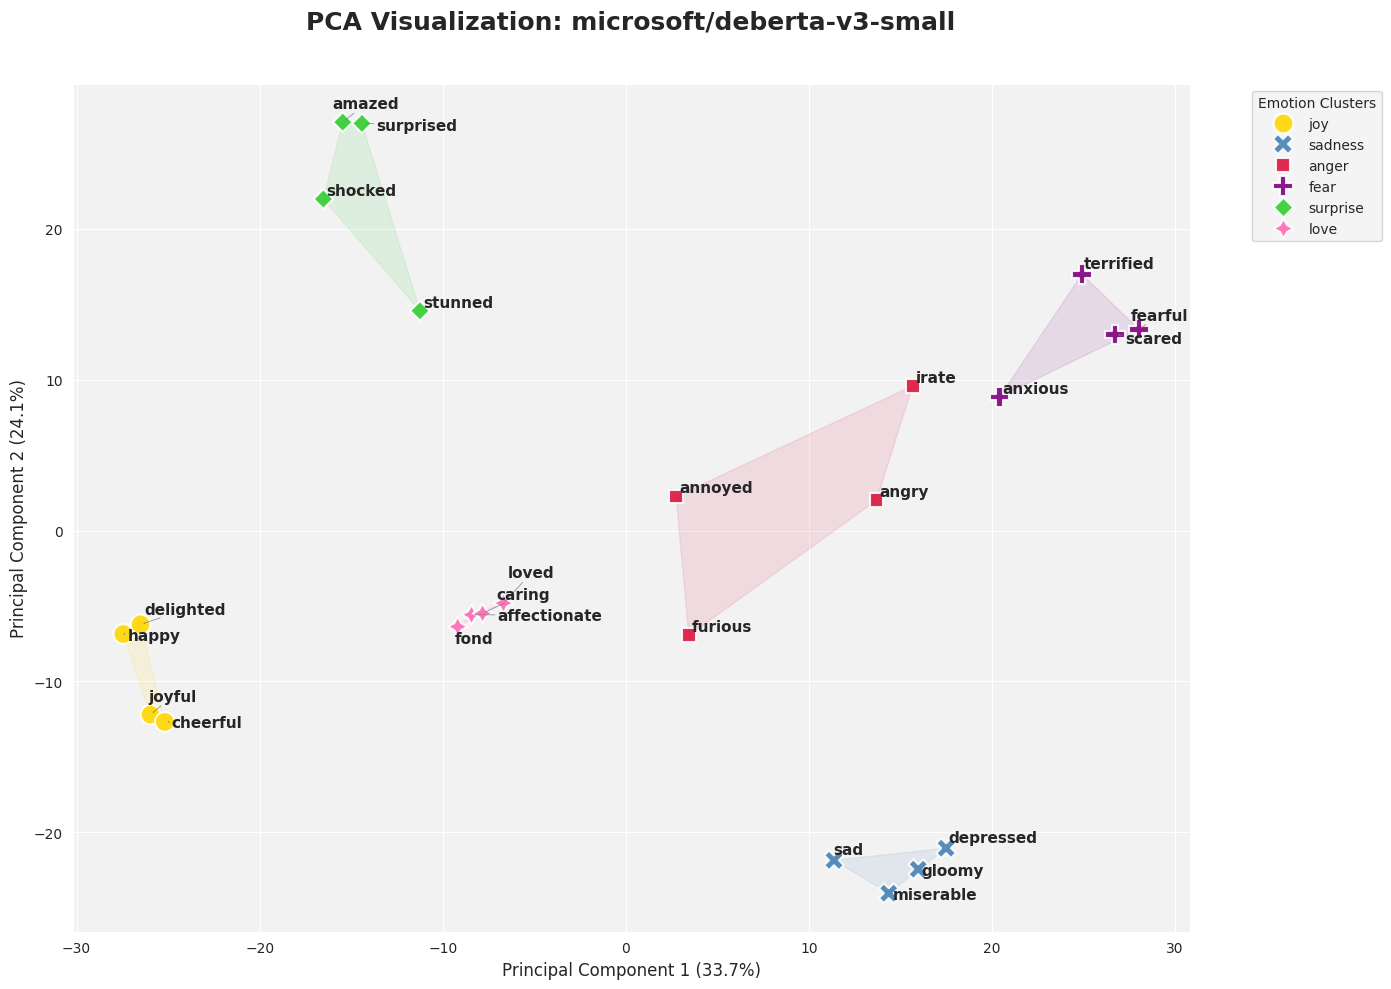

In [45]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
from adjustText import adjust_text
from scipy.spatial import ConvexHull

words = [
    ("happy", "joy"), ("joyful", "joy"), ("delighted", "joy"), ("cheerful", "joy"),
    ("sad", "sadness"), ("miserable", "sadness"), ("depressed", "sadness"), ("gloomy", "sadness"),
    ("angry", "anger"), ("furious", "anger"), ("annoyed", "anger"), ("irate", "anger"),
    ("scared", "fear"), ("terrified", "fear"), ("anxious", "fear"), ("fearful", "fear"),
    ("shocked", "surprise"), ("amazed", "surprise"), ("surprised", "surprise"), ("stunned", "surprise"),
    ("loved", "love"), ("affectionate", "love"), ("caring", "love"), ("fond", "love")
]

word_list = [item[0] for item in words]
emotion_labels = [item[1] for item in words]

model.eval()
word_embeddings = []
for word in word_list:
    inputs = tokenizer(word, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.deberta(**inputs)
        embeddings = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
        word_embeddings.append(embeddings[0])

pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(np.array(word_embeddings))
var_explained = pca.explained_variance_ratio_

df_pca = pd.DataFrame({
    'PC1': reduced_embeddings[:, 0],
    'PC2': reduced_embeddings[:, 1],
    'Word': word_list,
    'Emotion': emotion_labels
})

plt.figure(figsize=(14, 10), dpi=100)
sns.set_style("darkgrid", {"axes.facecolor": ".95"})

emotion_colors = {
    "joy": "#FFD700", "sadness": "#4682B4", "anger": "#DC143C",
    "fear": "#800080", "surprise": "#32CD32", "love": "#FF69B4"
}

for emotion in df_pca['Emotion'].unique():
    subset = df_pca[df_pca['Emotion'] == emotion]
    if len(subset) > 2:
        points = subset[['PC1', 'PC2']].values
        hull = ConvexHull(points)
        plt.fill(points[hull.vertices, 0], points[hull.vertices, 1],
                 color=emotion_colors[emotion], alpha=0.1)

scatter = sns.scatterplot(
    x='PC1', y='PC2', hue='Emotion', style='Emotion', data=df_pca,
    s=200, alpha=0.9, palette=emotion_colors, edgecolor="w", linewidth=1.5
)

texts = []
for i, row in df_pca.iterrows():
    texts.append(plt.text(row['PC1'], row['PC2'], row['Word'],
                         fontsize=11, fontweight='semibold'))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

plt.title(f"PCA Visualization: {model.config._name_or_path}\n",
          fontsize=18, fontweight='bold', pad=20)

plt.xlabel(f"Principal Component 1 ({var_explained[0]*100:.1f}%)", fontsize=12)
plt.ylabel(f"Principal Component 2 ({var_explained[1]*100:.1f}%)", fontsize=12)

plt.legend(title='Emotion Clusters', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()